In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install sklearn

In [ ]:
import sklearn
import torch
import torch.nn as nn
from torch.autograd import Function
from torch.autograd import Variable
import torch.utils.data as data_utils
import seaborn as sns
import pandas as pd
import torch.nn.functional as F
import numpy as np
from sklearn.model_selection import train_test_split
from torch import optim
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import keras
import sklearn
%matplotlib inline

In [ ]:
def remove_space_columns(data):
    temp={}
    for i in data:
        temp[i]=i.replace(' ','_')
    #print(temp)
    return temp

In [ ]:
data= pd.read_csv('/content/drive/My Drive/Colab Notebooks/CIN/duxin201903.csv',sep=';')

In [ ]:
data.rename(columns=remove_space_columns(data.columns),inplace=True)

In [ ]:
data

,Age,TCT,HPV_result,v_16,viral_load,v_18,viral_load.1,v_31,viral_load.2,v_33,viral_load.3,v_35,viral_load.4,v_39,viral_load.5,v_45,viral_load.6,v_51,viral_load.7,v_52,viral_load.8,v_56,viral_load.9,v_58,viral_load.10,v_59,viral_load.11,v_68,viral_load.12,Pathology
0,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5968,30,4,1,0,0,1,100000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
5969,47,1,1,1,100000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5970,37,4,1,0,0,1,10000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
5971,47,4,1,0,0,1,1000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
data.Pathology.replace([1],0,inplace=True)
data.Pathology.replace([2,3],1,inplace=True)

data.v_16

0       0
1       0
2       0
3       0
4       0
       ..
5968    0
5969    1
5970    0
5971    0
5972    0
Name: v_16, Length: 5973, dtype: int64

In [ ]:
data
max_p = data['viral_load'].max()
print(max_p)
data['viral_load'] = data['viral_load'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.1'] = data['viral_load.1'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.2'] = data['viral_load.2'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.3'] = data['viral_load.3'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.4'] = data['viral_load.4'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.5'] = data['viral_load.5'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.6'] = data['viral_load.6'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.7'] = data['viral_load.7'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.8'] = data['viral_load.8'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.9'] = data['viral_load.9'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.10'] = data['viral_load.10'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.11'] = data['viral_load.11'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data['viral_load.12'] = data['viral_load.12'].replace({10000000:7, 100000:5, 10000:4, 1000000:6, 1000:3, 100:2, 10:1})
data

10000000


,Age,TCT,HPV_result,v_16,viral_load,v_18,viral_load.1,v_31,viral_load.2,v_33,viral_load.3,v_35,viral_load.4,v_39,viral_load.5,v_45,viral_load.6,v_51,viral_load.7,v_52,viral_load.8,v_56,viral_load.9,v_58,viral_load.10,v_59,viral_load.11,v_68,viral_load.12,Pathology
0,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5968,30,4,1,0,0,1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5969,47,1,1,1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5970,37,4,1,0,0,1,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5971,47,4,1,0,0,1,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
y = data.Pathology
x = data.drop('Pathology', axis = 1)

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
x['viral_load'] = label_encoder.fit_transform(x['viral_load'])
x['viral_load.1'] = label_encoder.fit_transform(x['viral_load.1'])
x['viral_load.2'] = label_encoder.fit_transform(x['viral_load.2'])
x['viral_load.3'] = label_encoder.fit_transform(x['viral_load.3'])
x['viral_load.4'] = label_encoder.fit_transform(x['viral_load.4'])
x['viral_load.5'] = label_encoder.fit_transform(x['viral_load.5'])
x['viral_load.6'] = label_encoder.fit_transform(x['viral_load.6'])
x['viral_load.7'] = label_encoder.fit_transform(x['viral_load.7'])
x['viral_load.8'] = label_encoder.fit_transform(x['viral_load.8'])
x['viral_load.9'] = label_encoder.fit_transform(x['viral_load.9'])
x['viral_load.10'] = label_encoder.fit_transform(x['viral_load.10'])
x['viral_load.11'] = label_encoder.fit_transform(x['viral_load.11'])
x['viral_load.12'] = label_encoder.fit_transform(x['viral_load.12'])
# x['max_virus'] = label_encoder.fit_transform(x['max_virus'])

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
# k = 4 tells four top features to be selected
# Score function Chi2 tells the feature to be selected using Chi Square
test = SelectKBest(score_func=chi2, k=15)
fit = test.fit(x, y)
a=fit.scores_
a

array([9.33271394e+00, 3.21773731e+03, 1.18059188e+03, 1.18690351e+03,
       5.72560519e+03, 4.76830024e+01, 1.85797164e+02, 1.92754727e+02,
       8.22733585e+02, 1.86068059e+02, 5.99595380e+02, 3.97301551e+01,
       1.99136329e+02, 2.54904089e+01, 9.15011233e+01, 8.97129697e-01,
       1.79425939e+00, 6.77118866e+01, 2.03079125e+02, 1.52323061e+02,
       4.22995369e+02, 1.78132607e+01, 8.36888176e+01, 1.77647038e+02,
       8.52112994e+02, 7.29341598e+00, 7.16126913e+00, 4.71482121e+00,
       4.30830694e+00])

In [ ]:
b=x.columns
b

Index(['Age', 'TCT', 'HPV_result', 'v_16', 'viral_load', 'v_18',
       'viral_load.1', 'v_31', 'viral_load.2', 'v_33', 'viral_load.3', 'v_35',
       'viral_load.4', 'v_39', 'viral_load.5', 'v_45', 'viral_load.6', 'v_51',
       'viral_load.7', 'v_52', 'viral_load.8', 'v_56', 'viral_load.9', 'v_58',
       'viral_load.10', 'v_59', 'viral_load.11', 'v_68', 'viral_load.12'],
      dtype='object')

In [ ]:
dict(zip(a, b))

{0.8971296973091873: 'v_45',
 1.7942593946183747: 'viral_load.6',
 4.308306938470906: 'viral_load.12',
 4.714821206513135: 'v_68',
 7.161269128949922: 'viral_load.11',
 7.29341597628335: 'v_59',
 9.332713940434571: 'Age',
 17.813260660499516: 'v_56',
 25.490408936481344: 'v_39',
 39.73015512313391: 'v_35',
 47.683002362731514: 'v_18',
 67.7118866132647: 'v_51',
 83.68881757109116: 'viral_load.9',
 91.50112333589772: 'viral_load.5',
 152.32306050047856: 'v_52',
 177.6470379948669: 'v_58',
 185.797163894047: 'viral_load.1',
 186.06805923155036: 'v_33',
 192.7547268384766: 'v_31',
 199.1363293348483: 'viral_load.4',
 203.07912453430984: 'viral_load.7',
 422.99536891588593: 'viral_load.8',
 599.595380363779: 'viral_load.3',
 822.733584730415: 'viral_load.2',
 852.1129941094332: 'viral_load.10',
 1180.5918768640086: 'HPV_result',
 1186.9035107204927: 'v_16',
 3217.737308115471: 'TCT',
 5725.605190348369: 'viral_load'}

In [ ]:
chidrop = ['v_45','viral_load.6','viral_load.12','v_68','viral_load.11','v_59','Age','v_56','v_39','v_35','v_18','v_51','viral_load.9','viral_load.5',]
chiX = data.drop(chidrop, axis = 1)
chiX = chiX.drop('Pathology', axis = 1)
chiX

,TCT,HPV_result,v_16,viral_load,viral_load.1,v_31,viral_load.2,v_33,viral_load.3,viral_load.4,viral_load.7,v_52,viral_load.8,v_58,viral_load.10
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5968,4,1,0,0,5,0,0,0,0,0,0,0,0,0,0
5969,1,1,1,5,0,0,0,0,0,0,0,0,0,0,0
5970,4,1,0,0,4,0,0,0,0,0,0,0,0,0,0
5971,4,1,0,0,6,0,0,0,0,0,0,0,0,0,0


In [ ]:
x_new=test.fit_transform(x, y)
print(x_new)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [4 1 0 ... 0 0 0]
 [4 1 0 ... 0 0 0]
 [4 1 0 ... 0 0 0]]


In [ ]:
data

,Age,TCT,HPV_result,v_16,viral_load,v_18,viral_load.1,v_31,viral_load.2,v_33,viral_load.3,v_35,viral_load.4,v_39,viral_load.5,v_45,viral_load.6,v_51,viral_load.7,v_52,viral_load.8,v_56,viral_load.9,v_58,viral_load.10,v_59,viral_load.11,v_68,viral_load.12,Pathology
0,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5968,30,4,1,0,0,1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5969,47,1,1,1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5970,37,4,1,0,0,1,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5971,47,4,1,0,0,1,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df=chiX.copy()

Get dummies for the TCT columns

In [ ]:
dum=pd.get_dummies(df.TCT,prefix='TCT')

In [ ]:
dum

,TCT_0,TCT_1,TCT_2,TCT_3,TCT_4
0,1,0,0,0,0
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
...,...,...,...,...,...
5968,0,0,0,0,1
5969,0,1,0,0,0
5970,0,0,0,0,1
5971,0,0,0,0,1


In [ ]:
if 'TCT' in df.columns:
    del df['TCT']
if 'Age' in df.columns:
    del df['Age']

# df=pd.concat([df,dum],axis=1)

In [ ]:
col = df.columns
print(col)

Index(['HPV_result', 'v_16', 'viral_load', 'viral_load.1', 'v_31',
       'viral_load.2', 'v_33', 'viral_load.3', 'viral_load.4', 'viral_load.7',
       'v_52', 'viral_load.8', 'v_58', 'viral_load.10'],
      dtype='object')


In [ ]:
x=pd.concat([df,dum],axis=1)
x

,HPV_result,v_16,viral_load,viral_load.1,v_31,viral_load.2,v_33,viral_load.3,viral_load.4,viral_load.7,v_52,viral_load.8,v_58,viral_load.10,TCT_0,TCT_1,TCT_2,TCT_3,TCT_4
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5968,1,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5969,1,1,5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5970,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5971,1,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
y

0       0
1       0
2       0
3       0
4       0
       ..
5968    1
5969    0
5970    1
5971    0
5972    1
Name: Pathology, Length: 5973, dtype: int64

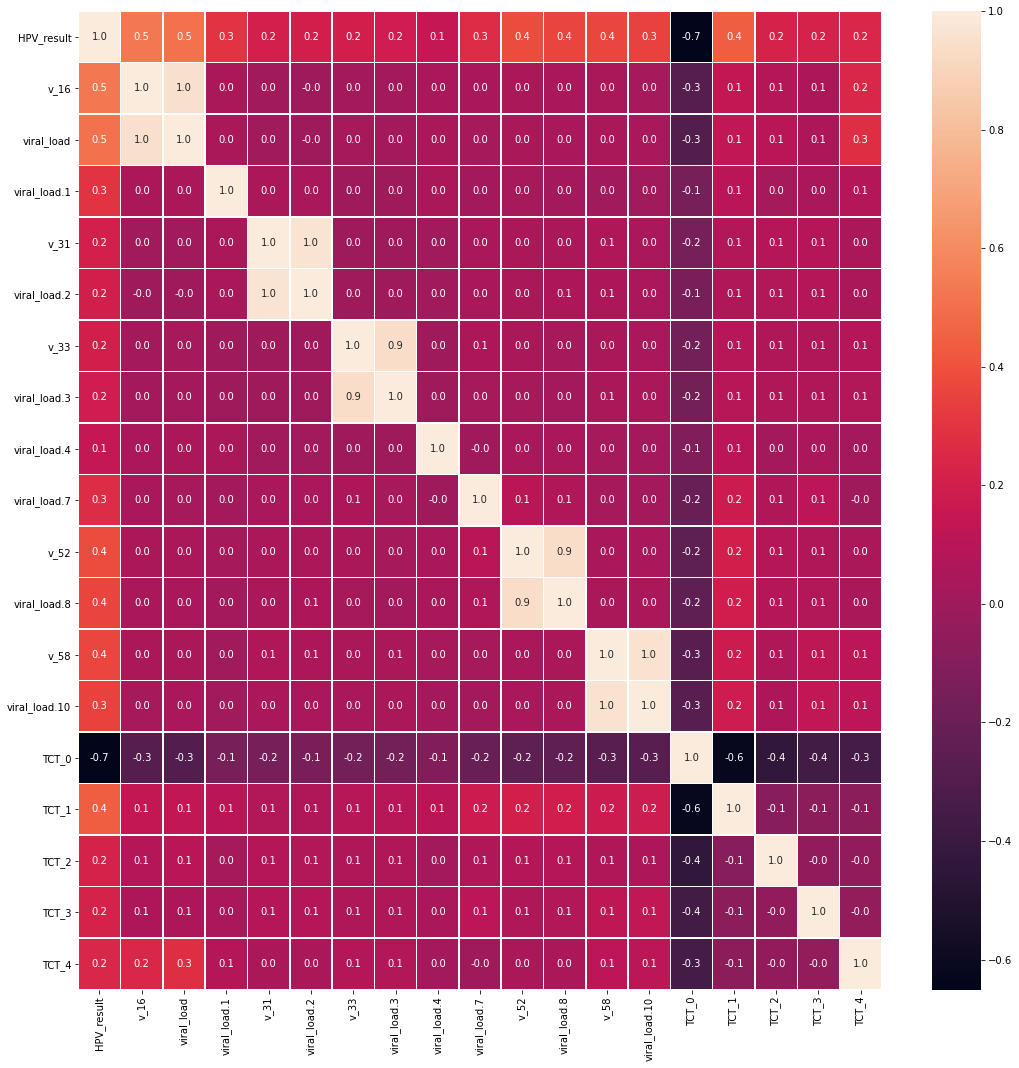

In [ ]:
#correlation map
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(x.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

Correlation map. Looking at the correlation mapping the viral_load and v_16 looks higly correlated. So choosing v_16 and droping viral_load

In [ ]:
X=x.copy()
Y=y
# del X['Pathology']
X=X
X.shape

# drop_list1 = ['viral_load','viral_load.2', 'viral_load.4', 'viral_load.6', 'viral_load.10', 'Agele24','Agebw24_34','AgeBw34_44','AgeBw44and54','AgeBw54and64', 'Ageabove64']
# X = X.drop(drop_list1 , axis =1)
# X.shape

(5973, 19)

In [ ]:
# first neural network with keras tutorial
from numpy import loadtxt
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import StratifiedKFold
import numpy as np
from keras import backend as K

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    f1 = 2*((precision*recall)/(precision+recall+K.epsilon()))
    return f1

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
# Define per-fold score containers
num_folds = 10
acc_per_fold = []
loss_per_fold = []
rec_per_fold = []
pre_per_fold = []
f1_per_fold = []

# Merge inputs and targets
inputs = np.concatenate((X_train, X_test), axis=0)
targets = np.concatenate((y_train, y_test), axis=0)

# Define the K-fold Cross Validator
kfold = StratifiedKFold(n_splits=num_folds, shuffle=True)

# K-fold Cross Validation model evaluation
fold_no = 1
for train, test in kfold.split(inputs, targets):
  X_train, X_test = inputs[train], inputs[test]
  y_train, y_test = targets[train], targets[test]
  # define the keras model
  model = Sequential()
  model.add(Dense(12, input_dim=19, activation='relu'))
  model.add(Dense(8, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))
  # compile the keras model
  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy',f1_m,precision_m, recall_m])
  # Generate a print
  print('------------------------------------------------------------------------')
  print(f'Training for fold {fold_no} ...')
  # fit the keras model on the dataset
  model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=100, batch_size=10)


  # Generate generalization metrics
  scores = model.evaluate(X_test, y_test, verbose=0)
  # f1_score, precision, recall = model.evaluate(X_test, y_test, verbose=0)
  print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
  print('Recall of ', scores[4])
  print('Precision of ', scores[3])
  print('F1score of ', scores[2])
  acc_per_fold.append(scores[1] * 100)
  loss_per_fold.append(scores[0])
  rec_per_fold.append(scores[4])
  pre_per_fold.append(scores[3])
  f1_per_fold.append(scores[2])

  # Increase fold number
  fold_no = fold_no + 1

# == Provide average scores ==
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
  print('------------------------------------------------------------------------')
  print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {acc_per_fold[i]}%')
  print(f'> Fold {i+1} - F1_Score: {f1_per_fold[i]} - Precision: {pre_per_fold[i]} - Recall: {rec_per_fold[i]}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')
print(f'> Recall: {np.mean(rec_per_fold)}')
print(f'> Precision: {np.mean(pre_per_fold)}')
print(f'> F1_score: {np.mean(f1_per_fold)}')
print('------------------------------------------------------------------------')



------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/100
538/538 [==============================] - 3s 4ms/step - loss: 0.4937 - accuracy: 0.8806 - f1_m: 0.1082 - precision_m: 0.1201 - recall_m: 0.1157 - val_loss: 0.1974 - val_accuracy: 0.9164 - val_f1_m: 0.2787 - val_precision_m: 0.3125 - val_recall_m: 0.2736
Epoch 2/100
538/538 [==============================] - 2s 4ms/step - loss: 0.1745 - accuracy: 0.9290 - f1_m: 0.3732 - precision_m: 0.4274 - recall_m: 0.3554 - val_loss: 0.1737 - val_accuracy: 0.9197 - val_f1_m: 0.3101 - val_precision_m: 0.3667 - val_recall_m: 0.2903
Epoch 3/100
538/538 [==============================] - 2s 3ms/step - loss: 0.1793 - accuracy: 0.9213 - f1_m: 0.3580 - precision_m: 0.3997 - recall_m: 0.3500 - val_loss: 0.1714 - val_accuracy: 0.9164 - val_f1_m: 0.3214 - val_precision_m: 0.3572 - val_recall_m: 0.3292
Epoch 4/100
538/538 [==============================] - 2s 3ms/step - loss: 0.1582 - accuracy: 0.9307 -

In [ ]:
X

,HPV_result,v_16,viral_load,viral_load.1,v_31,viral_load.2,v_33,viral_load.3,viral_load.4,viral_load.7,v_52,viral_load.8,v_58,viral_load.10,TCT_0,TCT_1,TCT_2,TCT_3,TCT_4
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5968,1,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5969,1,1,5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5970,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5971,1,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


Normalization the data between 0 and 1

In [ ]:
def Scalar(X,Y):
    min_max_scaler = preprocessing.MinMaxScaler()
    NUMERIC_COLUMN = ["viral_load","viral_load.1", "viral_load.2", "viral_load.3", "viral_load.4","viral_load.7","viral_load.8", "viral_load.10"]
    # ["viral_load.1", "viral_load.3", "viral_load.5", "viral_load.7","viral_load.8", "viral_load.9", "viral_load.11", "viral_load.12"]
    #["viral_load.2", "viral_load.3", "viral_load.4", "viral_load.5", "viral_load.6", "viral_load.7","viral_load.8", "viral_load.9", "viral_load.10", "viral_load.11", "viral_load.12"]
    #['viral_load','viral_load.2', 'viral_load.4', 'viral_load.6', 'viral_load.10']

    for i in NUMERIC_COLUMN:
        X[i]=min_max_scaler.fit_transform(X[i].values.astype('float32').reshape(-1,1))


    return X, Y


Convert the data from numpy array to torch tensor

In [ ]:

def getNewData():
    X1, Y1 = Scalar(X,Y)
    NUMERIC_COLUMN = ["viral_load","viral_load.1", "viral_load.2", "viral_load.3", "viral_load.4","viral_load.7","viral_load.8", "viral_load.10"]

    CATEGORICAL_COLUMN =  ["HPV_result", "v_16", "v_31", "v_33", "v_52",  "v_58"]

    LABEL_COLUMN = "Pathology"
    CATEGORICAL_COLUMN_WITH_IDENTITY = ["TCT_0", "TCT_1", "TCT_2", "TCT_3", "TCT_4"]

    for i in CATEGORICAL_COLUMN:
      X1[i]=np.array(X1[i].values.astype('float32'))
      # x_test[i]=np.array(x_test[i].values.astype('float32'))

    for i in X[CATEGORICAL_COLUMN]:
      X1[i]=np.array(X1[i].values.astype('int64'))
      # x_test[i]=np.array(x_test[i].values.astype('int64'))

    for i in X[CATEGORICAL_COLUMN_WITH_IDENTITY]:
      X1[i]=np.array(X1[i].values.astype('int64'))
      # x_test[i]=np.array(x_test[i].values.astype('int64'))

    Y1=pd.DataFrame(data=np.array(Y1.values.astype('int64')),columns=['Pathology'])
    # y_test=pd.DataFrame(data=np.array(y_test.values.astype('int64')),columns=['Pathology'])

    return X1, Y1


In [ ]:
X1, Y1 = getNewData()

Define base columns

In [ ]:
import tensorflow as tf
HPV_result = tf.feature_column.categorical_column_with_identity("HPV_result",  num_buckets=1000)
v_16 = tf.feature_column.categorical_column_with_identity("v_16",  num_buckets=1000)
viral_load = tf.feature_column.numeric_column("viral_load")
# v_18 = tf.feature_column.categorical_column_with_identity("v_18",  num_buckets=1000)
viral_load_1 = tf.feature_column.numeric_column("viral_load.1")
v_31 = tf.feature_column.categorical_column_with_identity("v_31",  num_buckets=1000)
viral_load_2 = tf.feature_column.numeric_column("viral_load.2")
v_33 = tf.feature_column.categorical_column_with_identity("v_33",  num_buckets=1000)
viral_load_3 = tf.feature_column.numeric_column("viral_load.3")
# v_35 = tf.feature_column.categorical_column_with_identity("v_35",  num_buckets=1000)
viral_load_4 = tf.feature_column.numeric_column("viral_load.4")
# v_39 = tf.feature_column.categorical_column_with_identity("v_39",  num_buckets=1000)
# viral_load_5 = tf.feature_column.numeric_column("viral_load.5")
# v_45 = tf.feature_column.categorical_column_with_identity("v_45",  num_buckets=1000)
# viral_load_6 = tf.feature_column.numeric_column("viral_load.6")
# v_51 = tf.feature_column.categorical_column_with_identity("v_51",  num_buckets=1000)
viral_load_7 = tf.feature_column.numeric_column("viral_load.7")
v_52 = tf.feature_column.categorical_column_with_identity("v_52",  num_buckets=1000)
viral_load_8 = tf.feature_column.numeric_column("viral_load.8")
# v_56 = tf.feature_column.categorical_column_with_identity("v_56",  num_buckets=1000)
# viral_load_9 = tf.feature_column.numeric_column("viral_load.9")
v_58 = tf.feature_column.categorical_column_with_identity("v_58",  num_buckets=1000)
viral_load_10 = tf.feature_column.numeric_column("viral_load.10")
# v_59 = tf.feature_column.categorical_column_with_identity("v_59",  num_buckets=1000)
# viral_load_11 = tf.feature_column.numeric_column("viral_load.11")
# v_68 = tf.feature_column.categorical_column_with_identity("v_68",  num_buckets=1000)
# viral_load_12 = tf.feature_column.numeric_column("viral_load.12")
# max_virus = tf.feature_column.numeric_column("max_virus")
TCT_0 = tf.feature_column.categorical_column_with_identity("TCT_0",  num_buckets=1000)
TCT_1 = tf.feature_column.categorical_column_with_identity("TCT_1",  num_buckets=1000)
TCT_2 = tf.feature_column.categorical_column_with_identity("TCT_2",  num_buckets=1000)
TCT_3 = tf.feature_column.categorical_column_with_identity("TCT_3",  num_buckets=1000)
TCT_4 = tf.feature_column.categorical_column_with_identity("TCT_4",  num_buckets=1000)

The wide model

In [ ]:
wide_columns = [
  HPV_result, v_16, v_31, v_33, v_52, v_58, TCT_0, TCT_1, TCT_2, TCT_3, TCT_4,
  tf.feature_column.crossed_column([HPV_result, TCT_0, TCT_1, TCT_2, TCT_3, TCT_4], hash_bucket_size=int(1e4))]

The deep model

In [ ]:
deep_columns = [
                # viral_load, viral_load_1, viral_load_2, viral_load_3, viral_load_4, viral_load_5, viral_load_6, viral_load_7,viral_load_8, viral_load_9, viral_load_10, viral_load_11, viral_load_12
  tf.feature_column.embedding_column(v_16, dimension=8),
  viral_load,
  # tf.feature_column.embedding_column(v_18, dimension=8),
  viral_load_1,
  tf.feature_column.embedding_column(v_31, dimension=8),
  viral_load_2,
  tf.feature_column.embedding_column(v_33, dimension=8),
  viral_load_3,
  # tf.feature_column.embedding_column(v_35, dimension=8),
  viral_load_4,
  # tf.feature_column.embedding_column(v_39, dimension=8),
  # viral_load_5,
  # tf.feature_column.embedding_column(v_45, dimension=8),
  # viral_load_6,
  # tf.feature_column.embedding_column(v_51, dimension=8),
  viral_load_7,
  tf.feature_column.embedding_column(v_52, dimension=8),
  viral_load_8,
  # tf.feature_column.embedding_column(v_56, dimension=8),
  # viral_load_9,
  tf.feature_column.embedding_column(v_58, dimension=8),
  viral_load_10]
  # tf.feature_column.embedding_column(v_59, dimension=8),
  # viral_load_11,
  # tf.feature_column.embedding_column(v_68, dimension=8),
  # viral_load_12]

Define model structure and start training

In [ ]:
from functools import partial
import tempfile
import pandas as pd
import urllib

from imblearn.pipeline import make_pipeline

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split, KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, roc_auc_score

from sklearn.model_selection import KFold

num_folds = 10

kfold = StratifiedKFold(n_splits=num_folds, shuffle=True)
kfold.get_n_splits(X1, Y1)
evals = []

# smoter = SMOTE(random_state=42)

for train_index, test_index in kfold.split(X1, Y1):


  COLUMNS = ["HPV_result", "v_16", "viral_load", "viral_load.1", "v_31", "viral_load.2", "v_33", "viral_load.3", "viral_load.4", "viral_load.7", "v_52", "viral_load.8", "v_58", "viral_load.10", "TCT_0", "TCT_1", "TCT_2", "TCT_3", "TCT_4"]
  CATEGORICAL_COLUMN = ["HPV_result", "v_16", "v_31", "v_33", "v_52",  "v_58"]

  LABEL_COLUMN = "Pathology"
  NUMERIC_COLUMN = ["viral_load", "viral_load.1", "viral_load.2", "viral_load.3", "viral_load.4",  "viral_load.7","viral_load.8",  "viral_load.10"]

  CATEGORICAL_COLUMN_WITH_IDENTITY = ["TCT_0", "TCT_1", "TCT_2", "TCT_3", "TCT_4"]




  def input_fn(df):


    x_data = df[0]
    # print(x_data["viral_load"])
    numeric_cols = {k: tf.constant(x_data[k].values)
                    for k in NUMERIC_COLUMN}


    categorical_cols = {k: tf.SparseTensor(
          indices = [[i, 0] for i in range(x_data[k].size)],
          values = x_data[k].values,
          dense_shape=[x_data[k].size,1])
          for k in CATEGORICAL_COLUMN}

    categorical_cols_with_identity = {k: tf.SparseTensor(
          indices=[[j, 0] for j in range(x_data[k].size)],
          values= x_data[k].values,
          dense_shape = [x_data[k].size,1])
                          for k in CATEGORICAL_COLUMN_WITH_IDENTITY}

    feature_cols  = numeric_cols.copy()
    feature_cols.update(categorical_cols)
    feature_cols.update(categorical_cols_with_identity)


    label = tf.constant(df[1].values)
    return feature_cols, label


  def train_input_fn(_x_train, _y_train):
    return input_fn([_x_train, _y_train])

  def eval_input_fn(_x_test, _y_test):
    return input_fn([_x_test, _y_test])


  def pred_input_fun(_y_test):
    return input_fn([_y_test])

  #Training trial 2
  from functools import partial


  import tempfile
  model_dir = tempfile.mkdtemp()
  m = tf.estimator.DNNLinearCombinedClassifier(model_dir=model_dir,
                                                  linear_feature_columns=wide_columns,
                                                  dnn_feature_columns=deep_columns,
                                                  dnn_hidden_units=[16, 128, 32], dnn_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                                                    dnn_activation_fn = tf.nn.relu)

  def training_loop(_X_test, _y_test, _X_train, _y_train ):
    training= m.train(
          input_fn = lambda:train_input_fn(_X_train, _y_train),
          steps=2000)
    results = m.evaluate(
        input_fn= lambda:eval_input_fn(_X_test, _y_test),
        steps=10)
    predictions = m.predict(
        input_fn= lambda:pred_input_fun (_y_test))
    evals.append(results)
    print('------------------------------------------------------------------------------------------------------------------------------------------------------------------------')
    return results, predictions
  # print("TRAIN:", train_index.shape, "TEST:", test_index.shape)
  # print(X.iloc[train_index])
  # print(Y.iloc[train_index])
  #X_test  = X[test_index]
  #print(X_train.shape)
  #print(y_train.shape)
  X_train, X_test = X1.iloc[train_index], X1.iloc[test_index]
  y_train, y_test = Y1.iloc[train_index], Y1.iloc[test_index]
  # X_train_upsample, y_train_upsample = SMOTE().fit_sample(X_train, y_train)



  # x_train = pd.DataFrame(X_train, columns=X_train)
  # x_test = pd.DataFrame(X_test, columns=X_test.columns)
  # y_train = pd.DataFrame(y_train)
  # y_test = pd.DataFrame(y_test)

  x_train = X_train
  x_test = X_test
  y_train = y_train
  y_test = y_test


  # NUMERIC_COLUMN = ["viral_load", "viral_load.1", "viral_load.2", "viral_load.3", "viral_load.4", "viral_load.5", "viral_load.6", "viral_load.7","viral_load.8", "viral_load.9", "viral_load.10", "viral_load.11", "viral_load.12", "max_virus"]

  # CATEGORICAL_COLUMN = ["HPV_result", "v_16", "v_18", "v_31", "v_33", "v_35", "v_39", "v_45", "v_51", "v_52", "v_56", "v_58", "v_59", "v_68"]

  # LABEL_COLUMN = "Pathology"
  # CATEGORICAL_COLUMN_WITH_IDENTITY = ["TCT_0", "TCT_1", "TCT_2", "TCT_3", "TCT_4", "Agele24", "Agebw24_34", "AgeBw34_44", "AgeBw44and54", "AgeBw54and64", "Ageabove64"]


  for i in CATEGORICAL_COLUMN:
    x_train[i]=np.array(x_train[i].values.astype('float32'))
    x_test[i]=np.array(x_test[i].values.astype('float32'))

  for i in X[CATEGORICAL_COLUMN]:
    x_train[i]=np.array(x_train[i].values.astype('int64'))
    x_test[i]=np.array(x_test[i].values.astype('int64'))

  for i in X[CATEGORICAL_COLUMN_WITH_IDENTITY]:
    x_train[i]=np.array(x_train[i].values.astype('int64'))
    x_test[i]=np.array(x_test[i].values.astype('int64'))

  y_train=pd.DataFrame(data=np.array(y_train.values.astype('int64')),columns=['Pathology'])
  y_test=pd.DataFrame(data=np.array(y_test.values.astype('int64')),columns=['Pathology'])
  # print(x_train)
  # print(y_test)
  model = training_loop(x_test, y_test, x_train, y_train)
  # evals.append(model.test(x_test, y_test))
  # evals.append(results, predictions)


INFO:tensorflow:Using default config.
INFO:tensorflow:Using config: {'_model_dir': '/tmp/tmp_yxbx79p', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}
Instructions for updating:
Use Variable.read_value. Variables in 2.X are initiali

/usr/local/lib/python3.7/dist-packages/sklearn/externals/six.py:31: FutureWarning: The module is deprecated in version 0.21 and will be removed in version 0.23 since we've dropped support for Python 2.7. Please rely on the official version of six (https://pypi.org/project/six/).
  "(https://pypi.org/project/six/).", FutureWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.neighbors.base module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.neighbors. Anything that cannot be imported from sklearn.neighbors is now part of the private API.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

INFO:tensorflow:Calling model_fn.


/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/base_layer_v1.py:1727: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use `layer.add_weight` method instead.
  warnings.warn('`layer.add_variable` is deprecated and '


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Create CheckpointSaverHook.
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.
INFO:tensorflow:Calling checkpoint listeners before saving checkpoint 0...
INFO:tensorflow:Saving checkpoints for 0 into /tmp/tmp_yxbx79p/model.ckpt.
INFO:tensorflow:Calling checkpoint listeners after saving checkpoint 0...
INFO:tensorflow:loss = 0.68681604, step = 0
INFO:tensorflow:global_step/sec: 47.252
INFO:tensorflow:loss = 0.19045058, step = 100 (2.121 sec)
INFO:tensorflow:global_step/sec: 60.6083
INFO:tensorflow:loss = 0.17877226, step = 200 (1.650 sec)
INFO:tensorflow:global_step/sec: 61.8574
INFO:tensorflow:loss = 0.17402959, step = 300 (1.613 sec)
INFO:tensorflow:global_step/sec: 60.7653
INFO:tensorflow:loss = 0.16999412, step = 400 (1.647 sec)
INFO:tensorflow:

In [ ]:
# dat = evals.items()
# dat1 = list(dat)
# # an_array = np.array(data)

# print(dat1)
for val in evals:
  print(val)

{'accuracy': 0.9130435, 'accuracy_baseline': 0.89464885, 'auc': 0.8858478, 'auc_precision_recall': 0.5811049, 'average_loss': 0.2699399, 'label/mean': 0.10535117, 'loss': 0.26993987, 'precision': 0.59016395, 'prediction/mean': 0.1107974, 'recall': 0.5714286, 'global_step': 2000}
{'accuracy': 0.92474914, 'accuracy_baseline': 0.8929766, 'auc': 0.83988774, 'auc_precision_recall': 0.5919168, 'average_loss': 0.31974316, 'label/mean': 0.10702341, 'loss': 0.31974316, 'precision': 0.7567568, 'prediction/mean': 0.09019423, 'recall': 0.4375, 'global_step': 2000}
{'accuracy': 0.93143815, 'accuracy_baseline': 0.8929766, 'auc': 0.9160815, 'auc_precision_recall': 0.71306103, 'average_loss': 0.24501756, 'label/mean': 0.10702341, 'loss': 0.24501756, 'precision': 0.7446808, 'prediction/mean': 0.102453336, 'recall': 0.546875, 'global_step': 2000}
{'accuracy': 0.919598, 'accuracy_baseline': 0.89447236, 'auc': 0.94493496, 'auc_precision_recall': 0.5707739, 'average_loss': 0.3034572, 'label/mean': 0.105527

In [ ]:
# evals

# for key, value in evals.iteritems():
#     temp = [key,value]
#     dictlist.append(temp)

def get_avg(listObj,keyword):
  listValues=[]
  for val in evals:
    for keys, values in val.items():
      if keys==keyword:
        listValues.append(values)
  mean = sum(listValues) / len(listValues)
  return {keyword:mean}

print(get_avg(evals, "accuracy"))
print(get_avg(evals, "accuracy_baseline"))
print(get_avg(evals, "auc"))
print(get_avg(evals, "auc_precision_recall"))
print(get_avg(evals, "average_loss"))
print(get_avg(evals, "label/mean"))
print(get_avg(evals, "loss"))
print(get_avg(evals, "precision"))
print(get_avg(evals, "prediction/mean"))
print(get_avg(evals, "recall"))
print(get_avg(evals, "global_step"))




# avgDict = {}
# for k,v in StudentGrades.iteritems():
#     # v is the list of grades for student k
#     avgDict[k] = sum(v)/ float(len(v))

# for val in evals:
#   for keys, values in evals.items():
#   print(val)
# # avg={'keys': 'values'}
# # l=[]
# # for keys, values in evals.items():
# #   if keys == 'accuracy':
# # avg['keys']=



{'accuracy': 0.9244942665100098}
{'accuracy_baseline': 0.8941908538341522}
{'auc': 0.9082441985607147}
{'auc_precision_recall': 0.6303285658359528}
{'average_loss': 0.26717204600572586}
{'label/mean': 0.10580914691090584}
{'loss': 0.26717205047607423}
{'precision': 0.6981669962406158}
{'prediction/mean': 0.10394426584243774}
{'recall': 0.5285962462425232}
{'global_step': 2000.0}
